# 🎯 KNN Imputation vs Traditional Simple Imputation (Mean/Median)

This notebook provides an educational walkthrough demonstrating how **K-Nearest Neighbors (KNN) Imputation** works compared to basic univariate imputation methods (**Mean** and **Median**) using a linearly dependent synthetic dataset.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer

# Set seed for reproducibility
np.random.seed(42)

### 📊 Step 1: Generate Synthetic Linear Dataset
We generate a linear relationship where **Salary** directly correlates with **Experience** (with some added random Gaussian noise) to see how effectively different imputers preserve this correlation.


In [5]:
# Generate synthetic linear data (Experience vs Salary)
experience = np.linspace(1, 15, 100)
salary = 40000 + experience * 5000 + np.random.normal(0, 5000, 100)

# Create a DataFrame
df = pd.DataFrame({'Experience': experience, 'Salary': salary})

### ✂️ Step 2: Introduce Artificial Missing Values (MCAR)
We randomly drop around 20% of the data in the `Salary` column to simulate **Missing Completely At Random (MCAR)** states.

In [6]:
# Introduce artificial missing values (Missing Completely at Random)
mask = np.random.rand(len(df)) < 0.2
df_missing = df.copy()
df_missing.loc[mask, 'Salary'] = np.nan

print(f"Total missing values introduced: {df_missing['Salary'].isnull().sum()}")

Total missing values introduced: 19


### 🛠️ Step 3: Initialize and Apply Imputation Techniques
We apply three strategies to fill the missing values:
1. **Mean Imputation:** Fills missing slots with the column average.
2. **Median Imputation:** Fills slots with the middle value of the sorted column.
3. **KNN Imputation:** Uses the feature space coordinates of the 3 nearest neighbors to mathematically guess the missing data point.

In [7]:
# Initialize Imputers
mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')
knn_imputer = KNNImputer(n_neighbors=3)

# Apply Imputation techniques
df_mean = df_missing.copy()
df_mean['Salary'] = mean_imputer.fit_transform(df_missing[['Salary']])

df_median = df_missing.copy()
df_median['Salary'] = median_imputer.fit_transform(df_missing[['Salary']])

df_knn = df_missing.copy()
df_knn['Salary'] = knn_imputer.fit_transform(df_missing[['Experience', 'Salary']])[:, 1]

### 🎨 Step 4: Visualize and Compare the Distributions
Let's look at the plots to analyze the behavior.
- **Observation:** Notice how Mean/Median imputations form an artificial horizontal line because they ignore the cross-feature dependencies, whereas **KNN Imputation successfully maps the missing dots along the original upward diagonal linear trend line.**

In [8]:
def plot_data(ax, data, title, original):
    """
    Helper function to plot original vs imputed data distribution.
    """
    ax.scatter(original['Experience'], original['Salary'], color='gray', alpha=0.5, label='Original Data')
    ax.scatter(data['Experience'], data['Salary'], color='blue', alpha=0.7, label='Imputed Data')
    ax.set_title(title)
    ax.set_xlabel('Experience (Years)')
    ax.set_ylabel('Salary ($)')
    ax.legend()

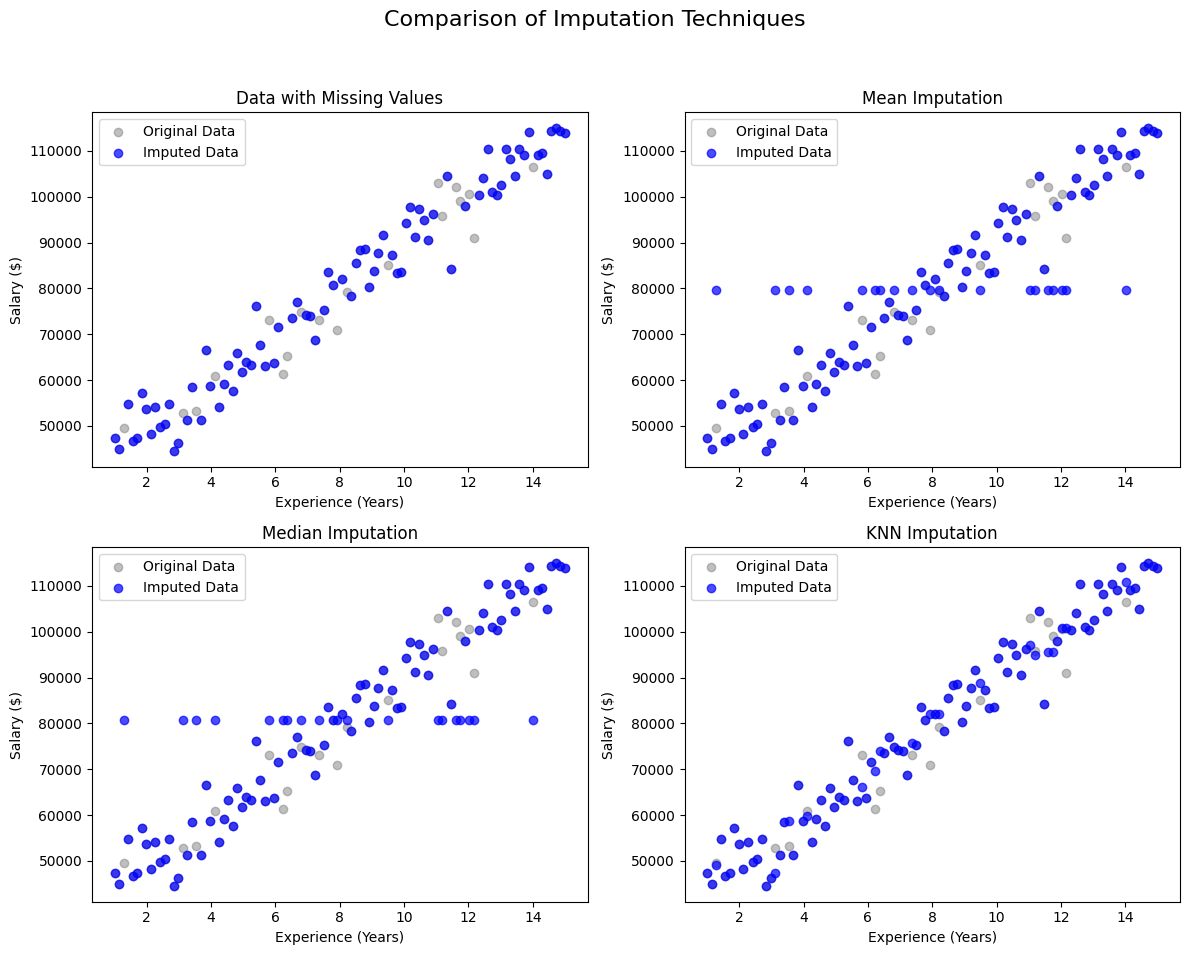

In [9]:
# Set up a 2x2 subplot canvas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparison of Imputation Techniques', fontsize=16)

# Execute plotting for each variant
plot_data(axes[0, 0], df_missing, 'Data with Missing Values', df)
plot_data(axes[0, 1], df_mean, 'Mean Imputation', df)
plot_data(axes[1, 0], df_median, 'Median Imputation', df)
plot_data(axes[1, 1], df_knn, 'KNN Imputation', df)

# Adjust layout structure to prevent suptitle clipping
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

# Explicitly display the plots inside the notebook
plt.show()

# Close the figure instance to free up resources
plt.close(fig)